In [1]:
%matplotlib inline

In [2]:
from pathlib import Path
import hashlib
import textwrap

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, to_rgb, to_hex
from matplotlib.patches import Patch, Rectangle
from matplotlib.ticker import MultipleLocator
import matplotlib.patheffects as pe

def apply_figure_style():
    mpl.rcParams.update({
        'font.family': 'DejaVu Sans', 'font.size': 10,
        'axes.labelsize': 10, 'axes.titlesize': 10,
        'legend.fontsize': 9, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
        'axes.linewidth': 0.6, 'xtick.direction': 'out', 'ytick.direction': 'out',
        'xtick.major.size': 3, 'ytick.major.size': 3,
        'legend.frameon': False, 'axes.grid': False,
        'figure.dpi': 140, 'savefig.dpi': 300,
        'pdf.fonttype': 42, 'ps.fonttype': 42,
    })

apply_figure_style()
ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "in" / "Figure2").is_dir()),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Open Figure2.ipynb from the repository folder containing in/Figure2.")
DATA = ROOT / "in" / "Figure2"
OUT = ROOT / "results" / "Figure2"
OUT.mkdir(parents=True, exist_ok=True)

In [3]:
EXPECTED_SHA256 = {'figure4a2_IL2_STAT5_SIGNALING.csv': '1e24e367e1c815cf0ad1eb1ac1e7072442731f00e794118083486decadef29e3', 'figure4a3_top_pathway.csv': 'ec6b20879c4a4a1e6d9b544bc769297b78b30e5588c18e6e4d98ea873e0d7e50', '2b.csv': '4ca16627e67c3dca3d203a60b6c911d217f29b7ed6cdea3696777fc687d03ec9', '2c.csv': '37b599ea472cf5be7250cb67764b5683605cf9ebc4337bf1e541a5342c9b252e'}
for name, expected in EXPECTED_SHA256.items():
    actual = hashlib.sha256((DATA / name).read_bytes()).hexdigest()
    if actual != expected:
        raise ValueError(f"Input checksum mismatch: {name}")

spatial = pd.read_csv(DATA / 'figure4a2_IL2_STAT5_SIGNALING.csv')
pathways = pd.read_csv(DATA / 'figure4a3_top_pathway.csv')
genes = pd.read_csv(DATA / '2b.csv')
correlations = pd.read_csv(DATA / '2c.csv')

REGIONS = ['Top-left', 'Bottom-left', 'Bottom-middle']
LETTERS = dict(zip(REGIONS, 'ABC'))
GENE_RUNS = ['ZeroShot'] + [f'ROI_{x:.1f}mm' for x in np.arange(0.5, 4, 0.5)]
PATHWAY_RUNS = ['ZeroShot'] + [f'roi{int(x)}p{int(round((x % 1) * 10))}mm'
                             for x in np.arange(0.5, 4, 0.5)]
RUN_LABELS = ['ZeroShot'] + [f'ROI {x:.1f}mm' for x in np.arange(0.5, 4, 0.5)]

assert len(spatial) == 5317 and len(pathways) == 30
assert len(genes) == 32 and len(correlations) == 16
assert not spatial['row_id'].duplicated().any()
assert set(spatial['region']) == set(REGIONS)
assert set(pathways['region']) == set(REGIONS)
assert not pathways.duplicated(['region', 'pathway']).any()
assert not genes.duplicated(['Run', 'gene_set', 'gene_type']).any()
assert not correlations.duplicated(['method', 'label']).any()
assert np.isfinite(spatial[['x', 'y', 'score']]).all().all()
assert np.isfinite(pathways['mean_score']).all()
assert np.isfinite(genes[['median_r', 'q25', 'q75']]).all().all()
assert np.isfinite(correlations[['pearson_r', 'spearman_rho']]).all().all()
assert genes['q25'].le(genes['median_r']).all()
assert genes['median_r'].le(genes['q75']).all()
assert spatial['x'].between(spatial['x_min'], spatial['x_max']).all()
assert spatial['y'].between(spatial['y_min'], spatial['y_max']).all()
for region, n in zip(REGIONS, [1030, 2469, 1818]):
    assert (spatial['region'] == region).sum() == n
    rows = pathways.loc[pathways['region'] == region]
    assert len(rows) == 10 and rows['n_cells'].eq(n).all()
for (gene_type, gene_set), rows in genes.groupby(['gene_type', 'gene_set']):
    assert set(rows['Run']) == set(GENE_RUNS)
    assert rows['n'].eq(int(gene_set.split()[-1])).all()
for label, rows in correlations.groupby('label'):
    assert set(rows['method']) == set(PATHWAY_RUNS)
assert correlations['n'].eq(1941).all()

In [4]:
UM_PER_PIXEL = 0.2125
spatial_plot = spatial.copy()
spatial_plot['x_um'] = spatial.groupby('region')['x'].transform(lambda x: x - x.min()) * UM_PER_PIXEL
spatial_plot['y_um'] = spatial.groupby('region')['y'].transform(lambda y: y.max() - y) * UM_PER_PIXEL
SX, SY = spatial_plot['x_um'].max(), spatial_plot['y_um'].max()
SCORE_NORM = Normalize(spatial_plot['score'].min(), spatial_plot['score'].max())
GENE_COLORS = {'SVG': '#D1495B', 'Non-SVG': '#4C8DB8'}
ER_COLORS = {'ER early': '#EDA04B', 'ER late': '#72B7A1'}

pathway_names = sorted(pathways['pathway'].unique())
anchors = np.array([to_rgb(c) for c in ['#D1495B', '#EDAE49', '#4C8DB8', '#72B7A1', '#8E6C88']])
positions = np.linspace(0, len(anchors) - 1, len(pathway_names))
palette = np.array([np.interp(positions, np.arange(len(anchors)), anchors[:, j]) for j in range(3)]).T
PATHWAY_COLORS = dict(zip(pathway_names, [to_hex(np.floor(c * 255) / 255) for c in palette]))

def frame(ax):
    for spine in ax.spines.values():
        spine.set_color('#777777')
        spine.set_linewidth(.55)
    ax.set_facecolor('white')

def strip(ax, text):
    ax.add_patch(Rectangle((0, 1), 1, .12, transform=ax.transAxes,
                           facecolor='white', edgecolor='#777777', lw=.55, clip_on=False))
    ax.text(.5, 1.06, text, ha='center', va='center', transform=ax.transAxes, fontsize=10)

def letter(ax, text, x=-.16, y=1.16):
    ax.text(x, y, text, transform=ax.transAxes, fontsize=14, fontweight='bold',
            ha='left', va='bottom')

def draw_spatial(ax, region):
    d = spatial_plot.loc[spatial_plot.region.eq(region)]

    points = ax.scatter(d.x_um, d.y_um, c=d.score, cmap='viridis', norm=SCORE_NORM,
                        s=7.0, linewidths=0, rasterized=True, zorder=2)
    ax.set_xlim(-.05 * SX, 1.05 * SX)
    ax.set_ylim(-.05 * SY, 1.05 * SY)
    ax.set_aspect('equal', adjustable='box')
    ax.xaxis.set_major_locator(MultipleLocator(200))
    ax.yaxis.set_major_locator(MultipleLocator(200))
    ax.grid(color='#bfbfbf', lw=.3, zorder=0)
    ax.tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)
    dx, dy = d.x_um.max(), d.y_um.max()
    x0, y0 = .05 * dx, .07 * dy
    assert 200 < .8 * dx
    ax.plot([x0, x0 + 200], [y0, y0], c='white', lw=4, solid_capstyle='round', zorder=3)
    ax.plot([x0, x0 + 200], [y0, y0], c='black', lw=2, solid_capstyle='round', zorder=4)
    ax.text(x0 + 100, .16 * dy, '200 µm', ha='center', va='center', fontsize=9,
            path_effects=[pe.withStroke(linewidth=2.5, foreground='white')], zorder=5)
    frame(ax)
    strip(ax, LETTERS[region])
    return points

BAR_MIN = min(0, pathways.mean_score.min())
BAR_MAX = max(0, pathways.mean_score.max())
BAR_SPAN = BAR_MAX - BAR_MIN

def draw_pathways(ax, region, xlabel=False):
    d = pathways.loc[pathways.region.eq(region)].sort_values('mean_score', ascending=False)
    values = d.mean_score.to_numpy()
    ax.barh(np.arange(len(d)), values, color=[PATHWAY_COLORS[x] for x in d.pathway], height=.86)
    for y, value in enumerate(values):
        ax.text(value + (.003 if value >= 0 else -.003), y, f'{value:.2f}',
                va='center', ha='left' if value >= 0 else 'right', fontsize=8)
    ax.set_xlim(BAR_MIN - .15 * BAR_SPAN, BAR_MAX + .18 * BAR_SPAN)
    ax.set_ylim(len(d) - .45, -.65)
    ax.set_xticks([])
    ax.set_yticks([])
    if xlabel:
        ax.set_xlabel('Median ssGSEA score', labelpad=8)
    frame(ax)
    strip(ax, LETTERS[region])

def draw_pathway_legend(ax):
    ax.set_axis_off()
    handles = [Patch(facecolor=PATHWAY_COLORS[name], edgecolor='none',
                     label=textwrap.fill(name.replace('ssgsea_HALLMARK_', '').replace('_', ' '), 28))
               for name in pathway_names]
    legend = ax.legend(handles=handles, loc='center left', title='Pathway',
                       handlelength=1.0, handleheight=1.0, borderaxespad=0,
                       labelspacing=.35, handletextpad=.5, fontsize=9)
    legend.get_title().set_fontsize(10)
    legend._legend_box.align = 'left'

def draw_gene(ax, gene_type, gene_set, ylabel=False):
    d = genes.loc[genes.gene_type.eq(gene_type) & genes.gene_set.eq(gene_set)].set_index('Run').loc[GENE_RUNS]
    median = d.median_r.to_numpy()
    errors = np.vstack([median - d.q25.to_numpy(), d.q75.to_numpy() - median])
    ax.errorbar(np.arange(8), median, yerr=errors, fmt='o-', color=GENE_COLORS[gene_type],
                ms=3, lw=.9, elinewidth=.65, capsize=1.5, capthick=.65)
    group = genes.loc[genes.gene_type.eq(gene_type)]
    lo, hi = group.q25.min(), group.q75.max()
    ax.set_ylim(lo - .05 * (hi - lo), hi + .05 * (hi - lo))
    ax.set_xlim(-.6, 7.6)
    ax.set_xticks(np.arange(8), RUN_LABELS, rotation=60, ha='right')
    if ylabel:
        ax.set_ylabel('Median Pearson r\non validation cells')
    else:
        ax.tick_params(labelleft=False, left=False)
    ax.yaxis.set_major_locator(MultipleLocator(.1 if gene_type == 'SVG' else .05))
    strip(ax, f'{gene_set} {gene_type}')
    frame(ax)

def draw_correlations(ax):
    for label, color in ER_COLORS.items():
        d = correlations.loc[correlations.label.eq(label)].set_index('method').loc[PATHWAY_RUNS]
        ax.plot(np.arange(8), d.pearson_r, 'o-', color=color, ms=3, lw=.9, label=label)
    lo, hi = correlations.pearson_r.min(), correlations.pearson_r.max()
    ax.set_ylim(lo - .05 * (hi - lo), hi + .05 * (hi - lo))
    ax.set_xlim(-.35, 7.35)
    ax.set_xticks(np.arange(8), RUN_LABELS, rotation=60, ha='right')
    ax.set_ylabel('Pathway Pearson correlation')
    ax.yaxis.set_major_locator(MultipleLocator(.05))
    ax.legend(loc='lower center', bbox_to_anchor=(.5, 1.015), ncol=2,
              fontsize=8, columnspacing=.8, handlelength=1.2)
    frame(ax)

def make_figure():
    fig = plt.figure(figsize=(14, 10.5), facecolor='white')

    outer = fig.add_gridspec(2, 1, left=.065, right=.975, bottom=.13, top=.92,
                             height_ratios=[2.65, 1], hspace=.44)
    upper = outer[0].subgridspec(1, 6, width_ratios=[.45, 2.15, .14, .8, 2.5, 2.9], wspace=.20)
    map_grid = upper[0, 1].subgridspec(3, 1, hspace=.20)
    bar_grid = upper[0, 4].subgridspec(3, 1, hspace=.20)
    spatial_axes = [fig.add_subplot(map_grid[i, 0]) for i in range(3)]
    pathway_axes = [fig.add_subplot(bar_grid[i, 0]) for i in range(3)]
    for i, region in enumerate(REGIONS):
        scatter = draw_spatial(spatial_axes[i], region)
        draw_pathways(pathway_axes[i], region, xlabel=i == 2)
    fig.canvas.draw()

    p = spatial_axes[1].get_position()
    cax = fig.add_axes([p.x1 + .012, p.y0 + p.height * .18, .011, p.height * .64])
    cb = fig.colorbar(scatter, cax=cax, ticks=[-.2, 0, .2, .4])
    cb.ax.set_title('ssGSEA', fontsize=9, pad=9)
    cb.ax.tick_params(labelsize=8, length=2)
    cb.outline.set_visible(False)
    draw_pathway_legend(fig.add_subplot(upper[0, 5]))
    letter(spatial_axes[0], 'b', y=1.36)
    letter(pathway_axes[0], 'c', y=1.36)
    spatial_axes[0].text(.5, 1.20, 'HALLMARK\nIL2 STAT5 SIGNALING',
                         transform=spatial_axes[0].transAxes, ha='center', va='bottom',
                         fontsize=10, fontweight='bold')
    pathway_axes[0].text(.5, 1.22, 'Top 10 pathways per region',
                         transform=pathway_axes[0].transAxes, ha='center', va='bottom',
                         fontsize=10, fontweight='bold')
    lower = outer[1].subgridspec(1, 7, width_ratios=[1, 1, .28, 1, 1, .30, 1.12], wspace=.06)
    gene_axes = [fig.add_subplot(lower[0, i]) for i in [0, 1, 3, 4]]
    for ax, kind, subset, left in zip(gene_axes, ['SVG', 'SVG', 'Non-SVG', 'Non-SVG'],
                                     ['Top 20', 'Top 50', 'Top 20', 'Top 50'], [True, False, True, False]):
        draw_gene(ax, kind, subset, ylabel=left)
    corr_ax = fig.add_subplot(lower[0, 6])
    draw_correlations(corr_ax)
    letter(gene_axes[0], 'd', y=1.16)
    letter(gene_axes[2], 'e', y=1.16)
    letter(corr_ax, 'f', y=1.16)
    fig.canvas.draw()
    groups = {'b': spatial_axes + [cax], 'c': pathway_axes,
              'd': gene_axes[:2], 'e': gene_axes[2:], 'f': [corr_ax]}
    return fig, groups

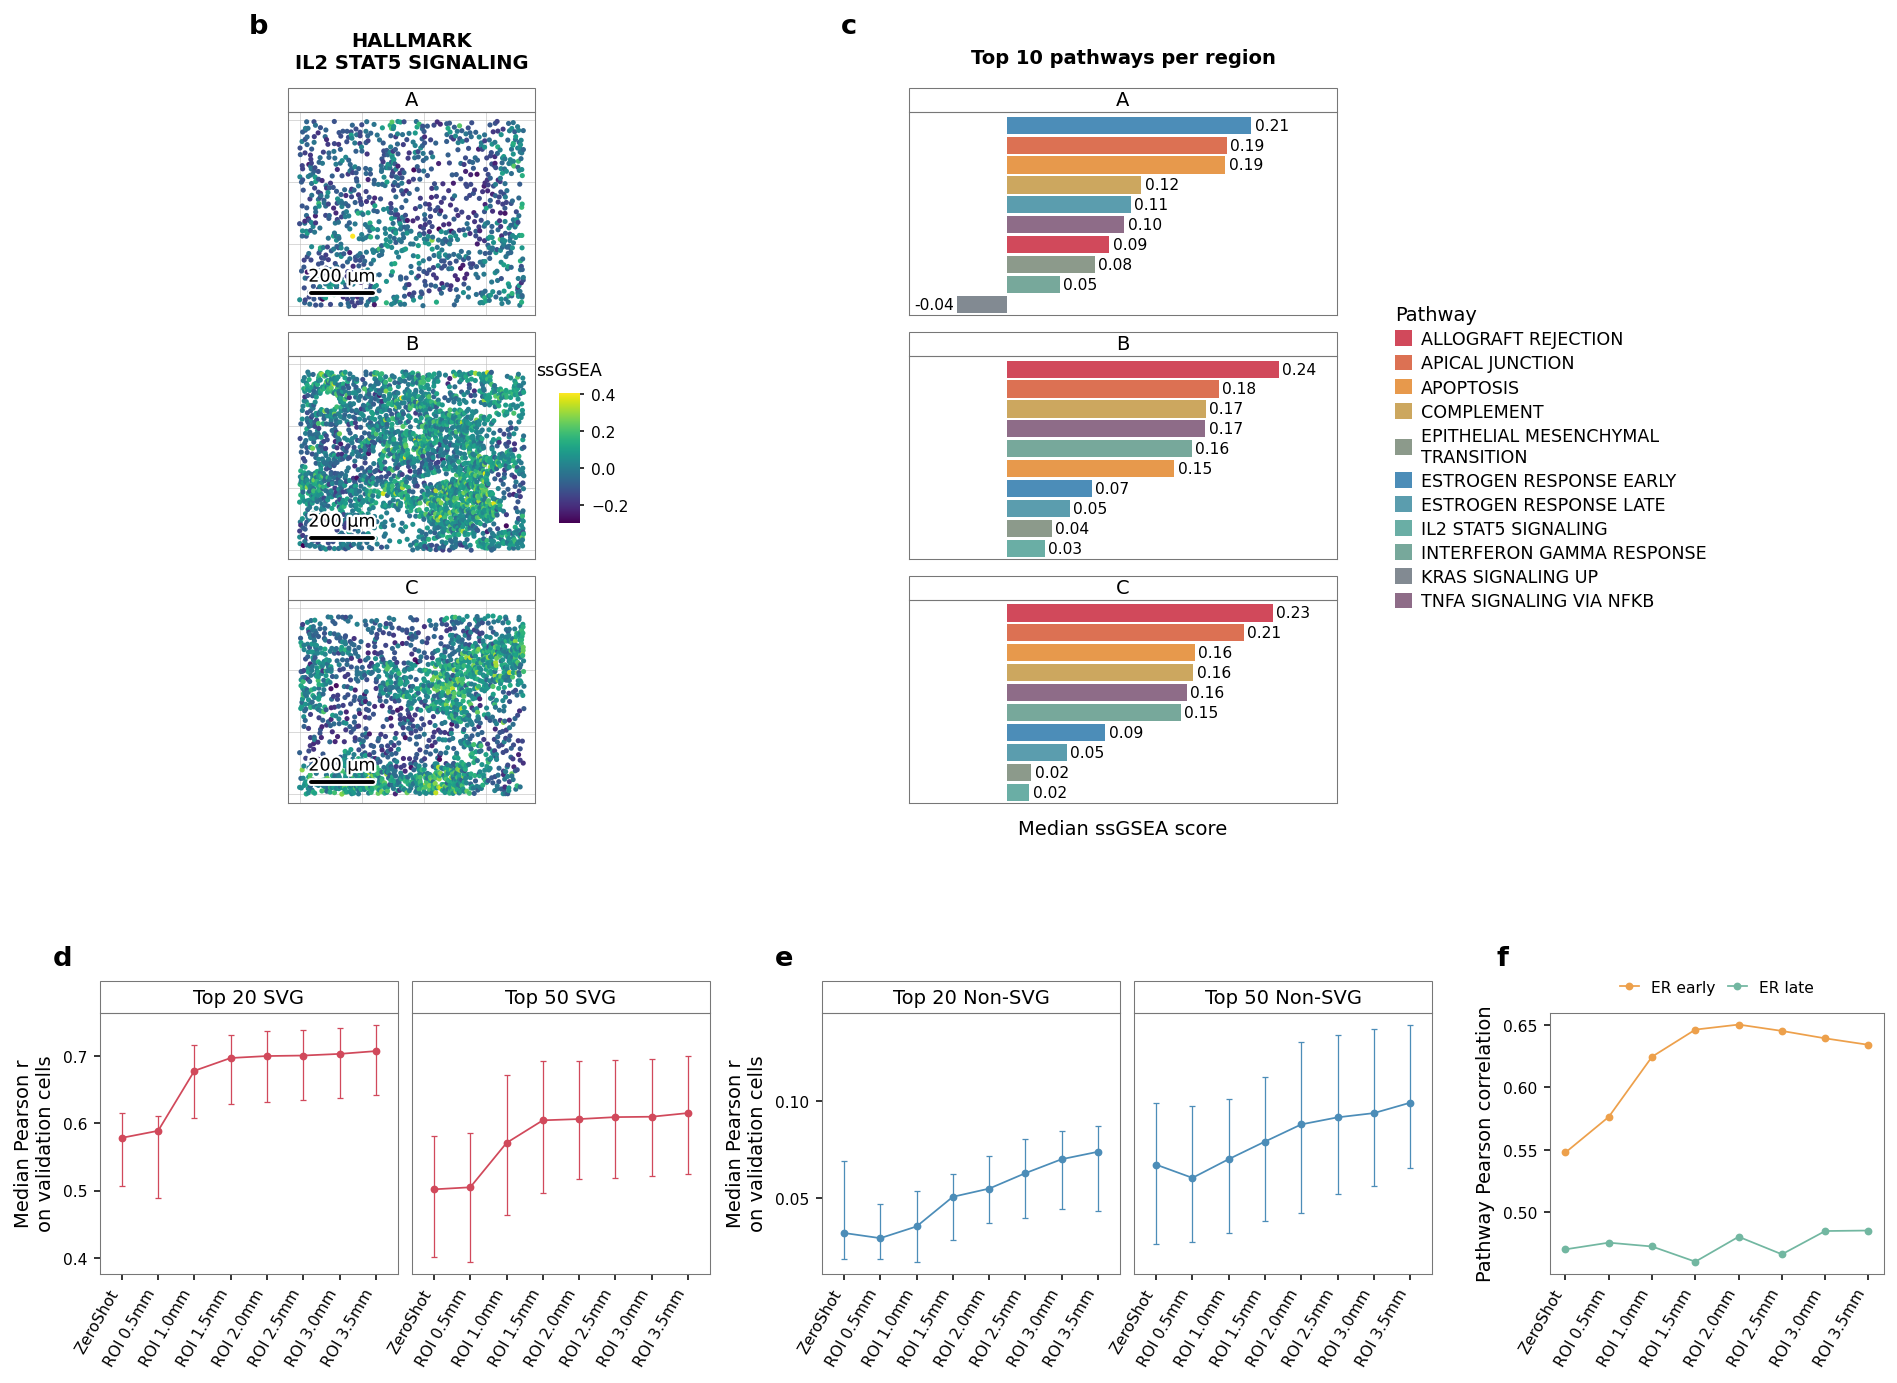

In [5]:
fig, panel_axes = make_figure()
fig.savefig(OUT / 'Figure2_panels_b_to_f.png', dpi=300, facecolor='white')
fig.savefig(OUT / 'Figure2_panels_b_to_f.pdf', dpi=300, facecolor='white')
plt.show()